In [1]:
import warnings
import pickle
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, accuracy_score, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, RandomizedSearchCV
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.utils.validation import check_is_fitted

warnings.simplefilter(action="ignore", category=FutureWarning)

In [2]:
def wrangle(location):
    df = pd.read_csv(location)
    df = df.dropna()
    df = df.reset_index(drop=True)
    return df

In [3]:
df = wrangle("student.csv")
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [4]:
df.describe()

,math_score,reading_score,writing_score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [5]:
target = "math_score"
x = df.drop(columns = target)
y = df[target]

In [6]:
X_train, X_test, Y_train, Y_test = train_test_split(x ,y ,test_size = 0.1, random_state = 11)

In [7]:
y_mean = Y_train.mean()

y_pred_baseline = [y_mean] * len(Y_train)

baseline_mae = mean_absolute_error(Y_train, y_pred_baseline)
print(f"Baseline MAE: {baseline_mae:.2f}")

Baseline MAE: 12.13


In [8]:
categorical_cols = X_train.select_dtypes("object").columns.tolist()
numeric_cols = X_train.select_dtypes("number").columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", "passthrough", numeric_cols)
    ]
)

model = Pipeline([
    ("preprocessing", preprocessor),
    ("regressor", DecisionTreeRegressor(random_state=11, max_depth=5))
])

model.fit(X_train, Y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [9]:
# 1. Generate predictions using the test set
Y_pred = model.predict(X_test)

# 2. Calculate Metrics
mae = mean_absolute_error(Y_test, Y_pred)
mse = mean_squared_error(Y_test, Y_pred)
rmse = mse**0.5  # Square root of MSE
r2 = r2_score(Y_test, Y_pred)

# 3. Calculate Baseline MAE for comparison
# (Predicting the mean of Y_train for every student)
y_baseline_pred = [Y_train.mean()] * len(Y_test)
baseline_mae = mean_absolute_error(Y_test, y_baseline_pred)

print(f"--- Model Performance ---")
print(f"Mean Absolute Error (MAE): {mae:.2f} points")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f} points")
print(f"R-squared Score ($R^2$): {r2:.2f}")
print(f"\n--- Baseline Performance ---")
print(f"Baseline MAE: {baseline_mae:.2f} points")

# Check if your model is actually better than the average guess
if mae < baseline_mae:
    print("\nSuccess: The outperformed the baseline!")
else:
    print("\nWarning: Your model is performing worse than just guessing the average.")

--- Model Performance ---
Mean Absolute Error (MAE): 5.47 points
Root Mean Squared Error (RMSE): 6.72 points
R-squared Score ($R^2$): 0.75

--- Baseline Performance ---
Baseline MAE: 11.12 points

Success: The outperformed the baseline!


In [10]:
mae_train = mean_absolute_error(Y_train, model.predict(X_train))
mae_test = mean_absolute_error(Y_test, model.predict(X_test))

print("Training MAE:", round(mae_train, 2))
print("Test MAE:", round(mae_test, 2))

Training MAE: 4.67
Test MAE: 5.47


In [11]:
tree_depth = model.named_steps["regressor"].get_depth()
print("Tree Depth:", tree_depth)

Tree Depth: 5


In [12]:
depth_hyperparams = range(1, 25, 1)
training_mae = []
test_mae = []

In [13]:
for d in depth_hyperparams:
    test_model = Pipeline([
        ("preprocessing", preprocessor), 
        ("regressor", DecisionTreeRegressor(random_state=42, max_depth=d))
    ])

    # Fit model
    test_model.fit(X_train, Y_train)
    
    # Calculate MAE scores
    training_mae.append(mean_absolute_error(Y_train, test_model.predict(X_train)))
    test_mae.append(mean_absolute_error(Y_test, test_model.predict(X_test)))


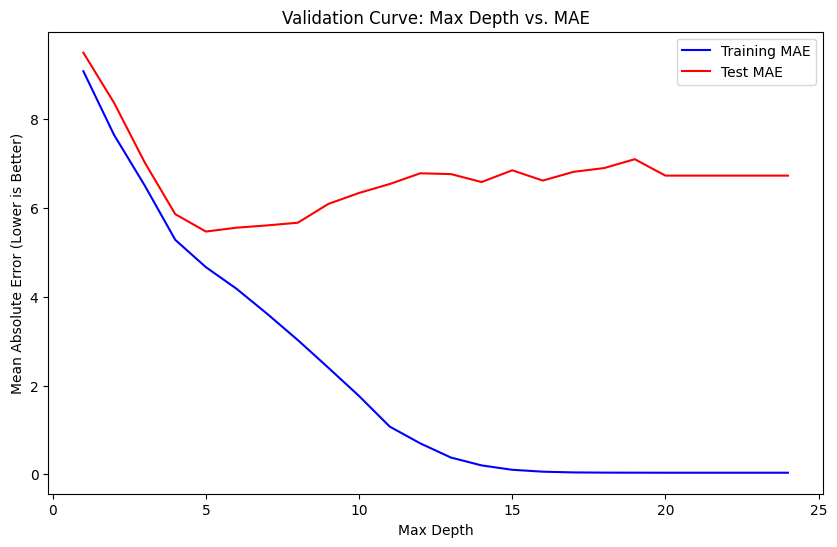

In [14]:
plt.figure(figsize=(10, 6))
plt.plot(depth_hyperparams, training_mae, label="Training MAE", color="blue")
plt.plot(depth_hyperparams, test_mae, label="Test MAE", color="red")

plt.xlabel("Max Depth")
plt.ylabel("Mean Absolute Error (Lower is Better)")
plt.title("Validation Curve: Max Depth vs. MAE")
plt.legend()
plt.show()

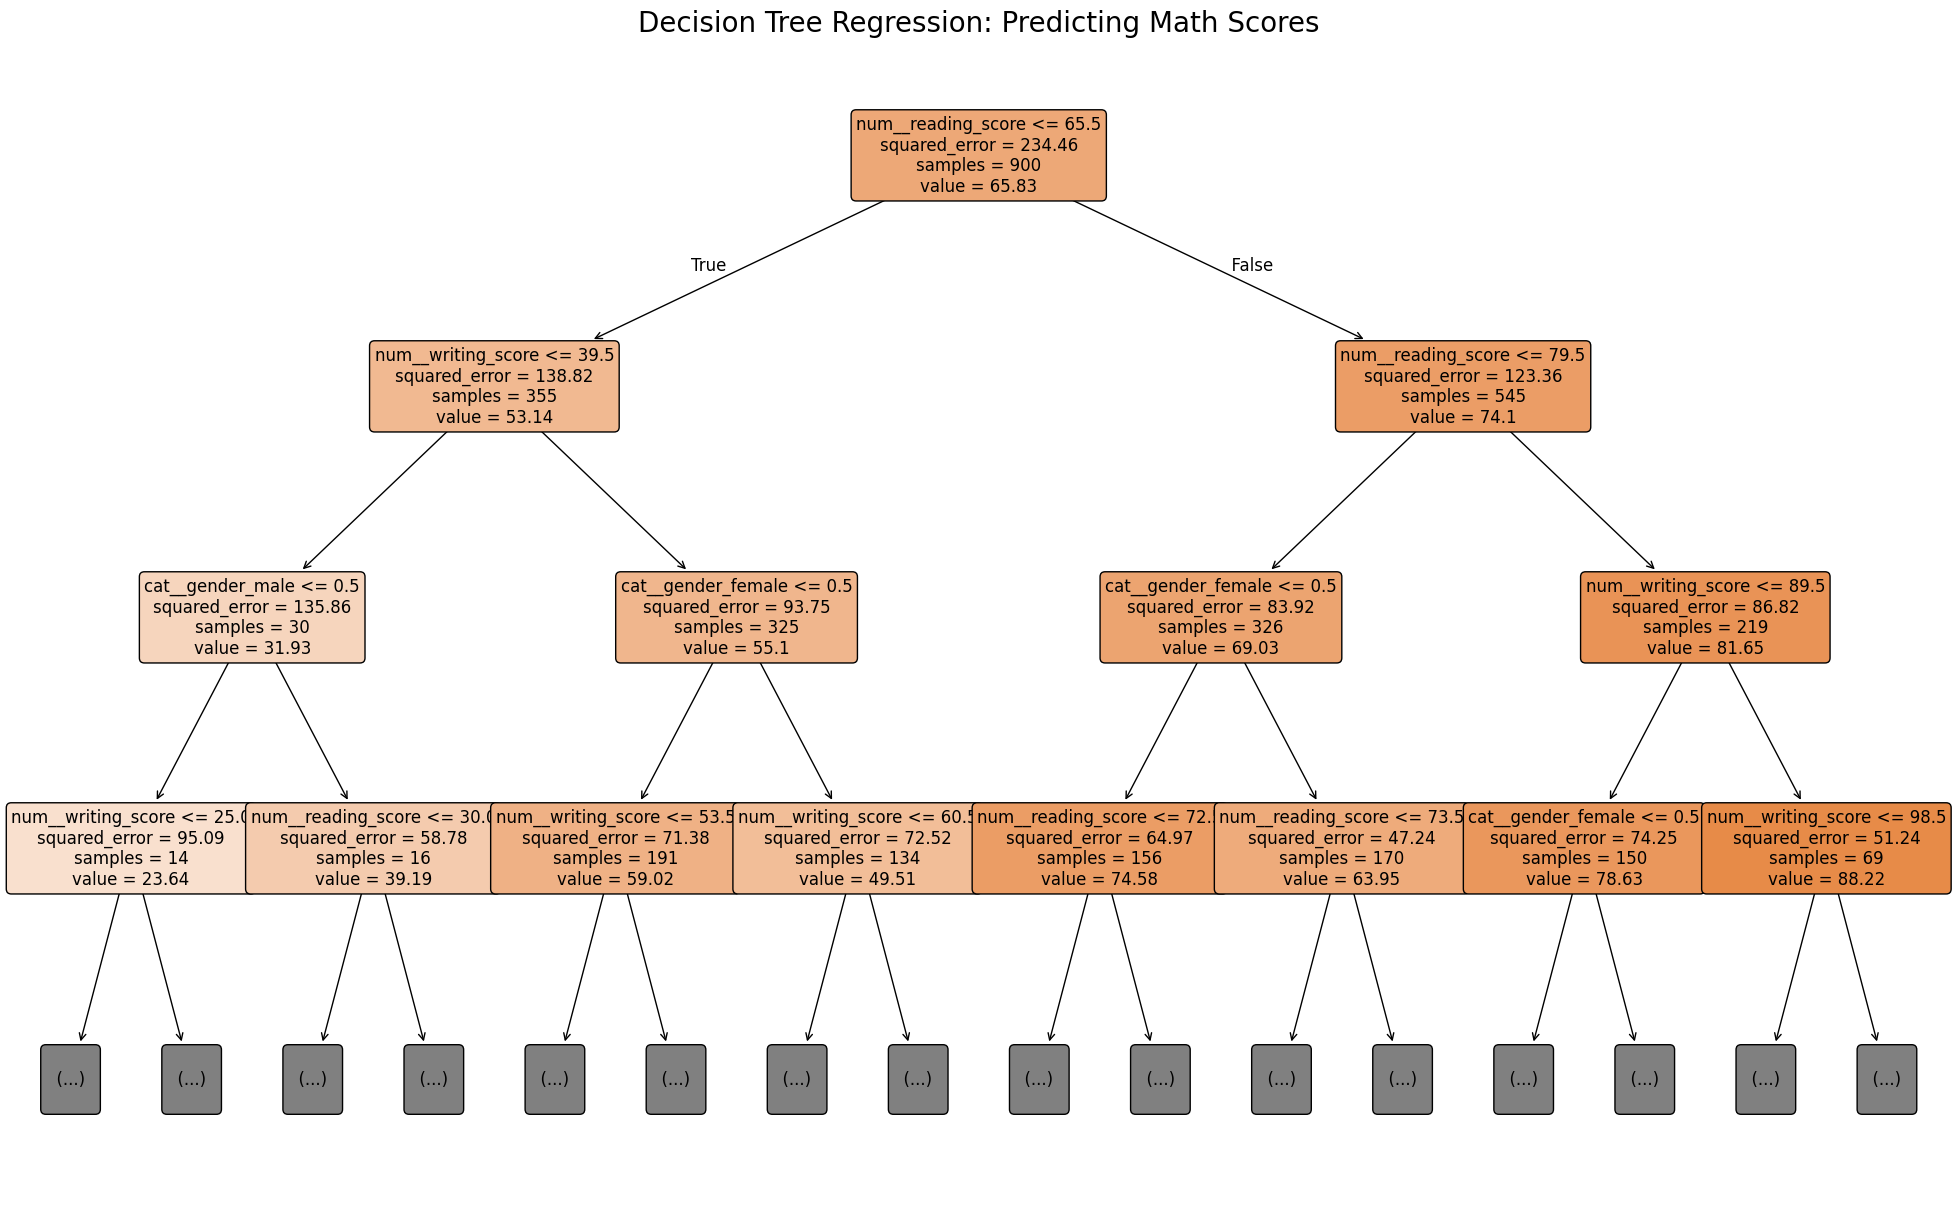

In [23]:
fig, ax = plt.subplots(figsize=(25, 15))

plot_tree(
    decision_tree=model.named_steps["regressor"],
    feature_names=model.named_steps["preprocessing"].get_feature_names_out(),
    filled=True,
    rounded=True,     
    precision=2,
    max_depth=3,
    fontsize=12,      
    ax=ax             
);

plt.title("Decision Tree Regression: Predicting Math Scores", fontsize=20)
plt.show()

In [16]:
features = model.named_steps["preprocessing"].get_feature_names_out()
importances = model.named_steps["regressor"].feature_importances_

<Axes: >

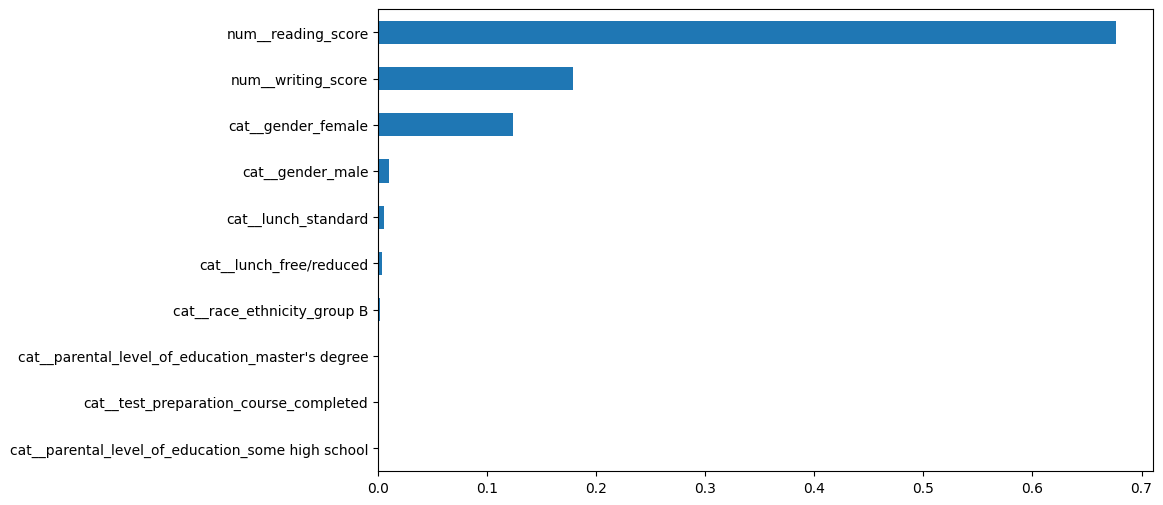

In [17]:
feat_imp = pd.Series(importances, index=features).sort_values(ascending=True)

feat_imp.tail(10).plot(kind="barh", figsize=(10, 6))

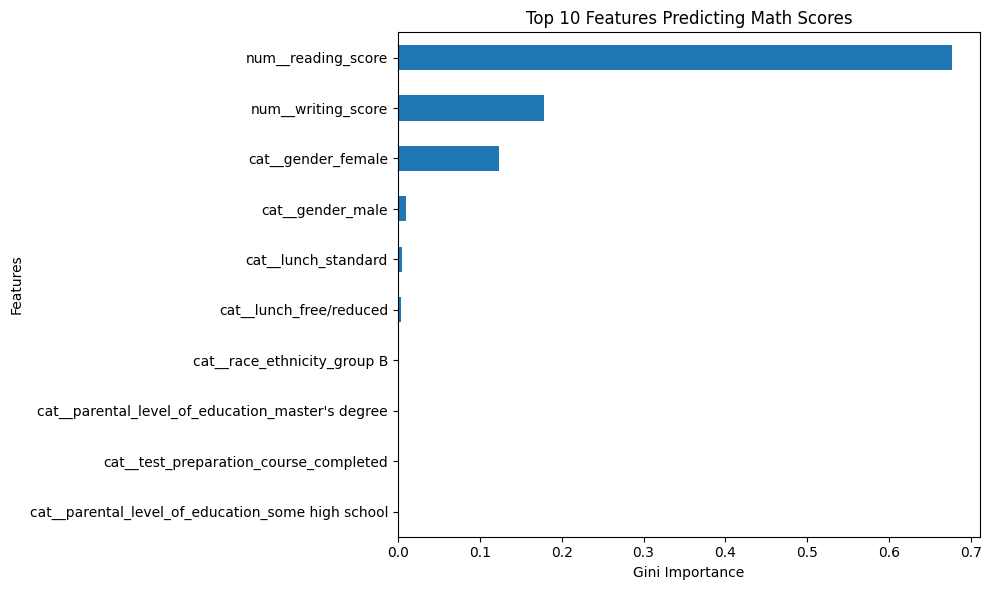

In [18]:
fig, ax = plt.subplots(figsize=(10, 6))

feat_imp.tail(10).plot(kind="barh", ax=ax)

plt.xlabel("Gini Importance")
plt.ylabel("Features")
plt.title("Top 10 Features Predicting Math Scores")
plt.tight_layout()
plt.show()

Feature Importance & Model Logic:
The feature importance analysis reveals that academic proficiency in other areas is the primary predictor of a student's math score. Specifically, Reading Score (0.67) and Writing Score (0.17) account for the vast majority of the model's predictive power. This suggests that the "Student Performance" dataset exhibits high multicollinearity; students who possess strong literacy and analytical skills are significantly more likely to excel in mathematics.Beyond test scores, Gender emerged as a notable demographic predictor, specifically with gender_female holding an importance of 0.12. Interestingly, categorical variables such as Lunch Type and Parental Level of Education showed negligible impact on this specific model's splits, suggesting that for this cohort, internal academic ability outweighs external socioeconomic factors in predicting specific score outcomes.

Model Performance vs. Baseline:
The decision tree regressor was evaluated against a Mean Baseline, which simply predicts the average math score for every student.

Baseline MAE: 11.12

Model MAE: 5.47

The model provides a more granular understanding of student needs. The significant reduction in Mean Absolute Error (MAE) compared to the baseline confirms that the model has successfully "learned" patterns from the features rather than just guessing the average.

Visualizing the Decision Process:
The visualization of the decision tree (limited to a depth of 3) confirms that the very first "split" or decision point the model makes is based on the Reading Score.

Students with reading scores below a certain threshold are branched into lower-scoring nodes.

Within those branches, the model then uses Writing Scores and Gender to further refine the prediction.
The tree structure demonstrates that while the model is complex, its logic is grounded in academic history, making it a transparent tool for educators to identify at-risk students based on their performance in other subjects.